<a href="https://colab.research.google.com/github/Amogh-S-Acharya/ML2-AMOGH_S_ACHARYA-4NI23CI012/blob/main/candidate_kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your Kaggle dataset
df = pd.read_csv("PlayTennis.csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower()

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())

display(df)


Dataset shape: (14, 5)

Columns: ['outlook', 'temp', 'humidity', 'windy', 'play']


,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
2,overcast,hot,high,False,yes
3,rainy,mild,high,False,yes
4,rainy,cool,normal,False,yes
5,rainy,cool,normal,True,no
6,overcast,cool,normal,True,yes
7,sunny,mild,high,False,no
8,sunny,cool,normal,False,yes
9,rainy,mild,normal,False,yes


In [9]:
features = ["outlook", "temp", "humidity", "windy"]
target = "play"

X = df[features]
y = df[target]

# Convert target to lowercase strings
y = y.astype(str).str.strip().str.lower()

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())


Features:


,outlook,temp,humidity,windy
0,sunny,hot,high,False
1,sunny,hot,high,True
2,overcast,hot,high,False
3,rainy,mild,high,False
4,rainy,cool,normal,False



Target:


,play
0,no
1,no
2,yes
3,yes
4,yes


In [10]:
def covers(hypothesis, example):
    """
    Returns True if hypothesis covers the example.
    '?' means any value.
    """

    for h, x in zip(hypothesis, example):

        if h != "?" and h != x:
            return False

    return True


In [11]:
def generalize_S(S, example):

    new_S = S.copy()

    for i in range(len(S)):

        # First positive example
        if new_S[i] == "∅":
            new_S[i] = example[i]

        # Different value -> generalize to ?
        elif new_S[i] != example[i]:
            new_S[i] = "?"

    return new_S


In [12]:
def specialize_G(G, S, example, domains):

    new_G = []

    for g in G:

        # If G already rejects the negative example,
        # keep it.
        if not covers(g, example):

            new_G.append(g)

        else:

            # G covers the negative example,
            # so specialize it.
            for i in range(len(g)):

                if g[i] == "?":

                    # Use values that are consistent with S
                    # but different from the negative example.
                    if S[i] != "∅" and S[i] != "?":

                        if S[i] != example[i]:

                            new_hypothesis = g.copy()

                            new_hypothesis[i] = S[i]

                            new_G.append(new_hypothesis)

    return new_G


In [13]:
def is_more_general_or_equal(g, s):

    for gv, sv in zip(g, s):

        # If S has no value yet
        if sv == "∅":
            continue

        # G can be anything
        if gv == "?":
            continue

        # Otherwise they must match
        if gv != sv:
            return False

    return True


In [14]:
def candidate_elimination(df):

    features = ["outlook", "temp", "humidity", "windy"]
    target = "play"

    X = df[features].values
    y = df[target].astype(str).str.strip().str.lower().values

    n_attributes = len(features)

    # --------------------------------
    # Initial S and G
    # --------------------------------

    S = ["∅"] * n_attributes

    G = [["?"] * n_attributes]

    # Attribute domains
    domains = []

    for feature in features:
        domains.append(
            sorted(df[feature].astype(str).unique())
        )

    # Store every step
    history = []

    # --------------------------------
    # Process every training example
    # --------------------------------

    for index in range(len(X)):

        example = list(X[index])
        label = y[index]

        # ==============================
        # POSITIVE EXAMPLE
        # ==============================

        if label == "yes":

            # Generalize S
            S = generalize_S(S, example)

            # G must cover positive example
            G = [
                g for g in G
                if covers(g, example)
            ]

        # ==============================
        # NEGATIVE EXAMPLE
        # ==============================

        elif label == "no":

            # Specialize G
            G = specialize_G(
                G,
                S,
                example,
                domains
            )

            # Keep only hypotheses
            # that are >= S
            G = [
                g for g in G
                if is_more_general_or_equal(g, S)
            ]

        # Remove duplicate G hypotheses
        unique_G = []

        for g in G:

            if g not in unique_G:
                unique_G.append(g)

        G = unique_G

        # --------------------------------
        # Save current state
        # --------------------------------

        history.append({
            "example_number": index + 1,
            "example": example,
            "label": label,
            "S": S.copy(),
            "G": [g.copy() for g in G]
        })

    return S, G, history


In [15]:
S_final, G_final, history = candidate_elimination(df)

print("FINAL SPECIFIC BOUNDARY (S)")
print(S_final)

print("\nFINAL GENERAL BOUNDARY (G)")

for g in G_final:
    print(g)


FINAL SPECIFIC BOUNDARY (S)
['?', '?', '?', '?']

FINAL GENERAL BOUNDARY (G)


In [16]:
for step in history:

    print("\n" + "=" * 70)

    print(
        f"Example {step['example_number']}: "
        f"{step['example']} --> "
        f"{step['label'].upper()}"
    )

    print("\nS:")
    print(step["S"])

    print("\nG:")

    if len(step["G"]) == 0:
        print("No hypotheses")

    else:
        for g in step["G"]:
            print(g)



Example 1: ['sunny', 'hot', 'high', False] --> NO

S:
['∅', '∅', '∅', '∅']

G:
No hypotheses

Example 2: ['sunny', 'hot', 'high', True] --> NO

S:
['∅', '∅', '∅', '∅']

G:
No hypotheses

Example 3: ['overcast', 'hot', 'high', False] --> YES

S:
['overcast', 'hot', 'high', False]

G:
No hypotheses

Example 4: ['rainy', 'mild', 'high', False] --> YES

S:
['?', '?', 'high', False]

G:
No hypotheses

Example 5: ['rainy', 'cool', 'normal', False] --> YES

S:
['?', '?', '?', False]

G:
No hypotheses

Example 6: ['rainy', 'cool', 'normal', True] --> NO

S:
['?', '?', '?', False]

G:
No hypotheses

Example 7: ['overcast', 'cool', 'normal', True] --> YES

S:
['?', '?', '?', '?']

G:
No hypotheses

Example 8: ['sunny', 'mild', 'high', False] --> NO

S:
['?', '?', '?', '?']

G:
No hypotheses

Example 9: ['sunny', 'cool', 'normal', False] --> YES

S:
['?', '?', '?', '?']

G:
No hypotheses

Example 10: ['rainy', 'mild', 'normal', False] --> YES

S:
['?', '?', '?', '?']

G:
No hypotheses

Example 1

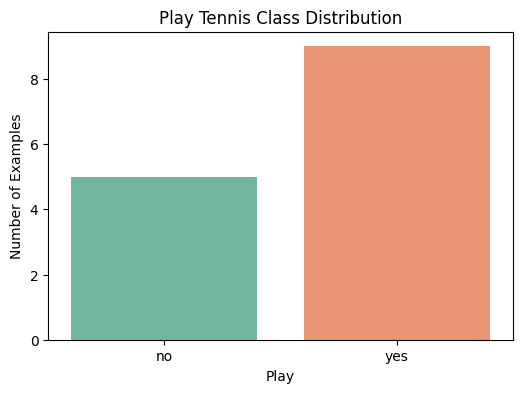

In [17]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="play",
    hue="play",
    palette="Set2",
    legend=False
)

plt.title("Play Tennis Class Distribution")
plt.xlabel("Play")
plt.ylabel("Number of Examples")

plt.show()


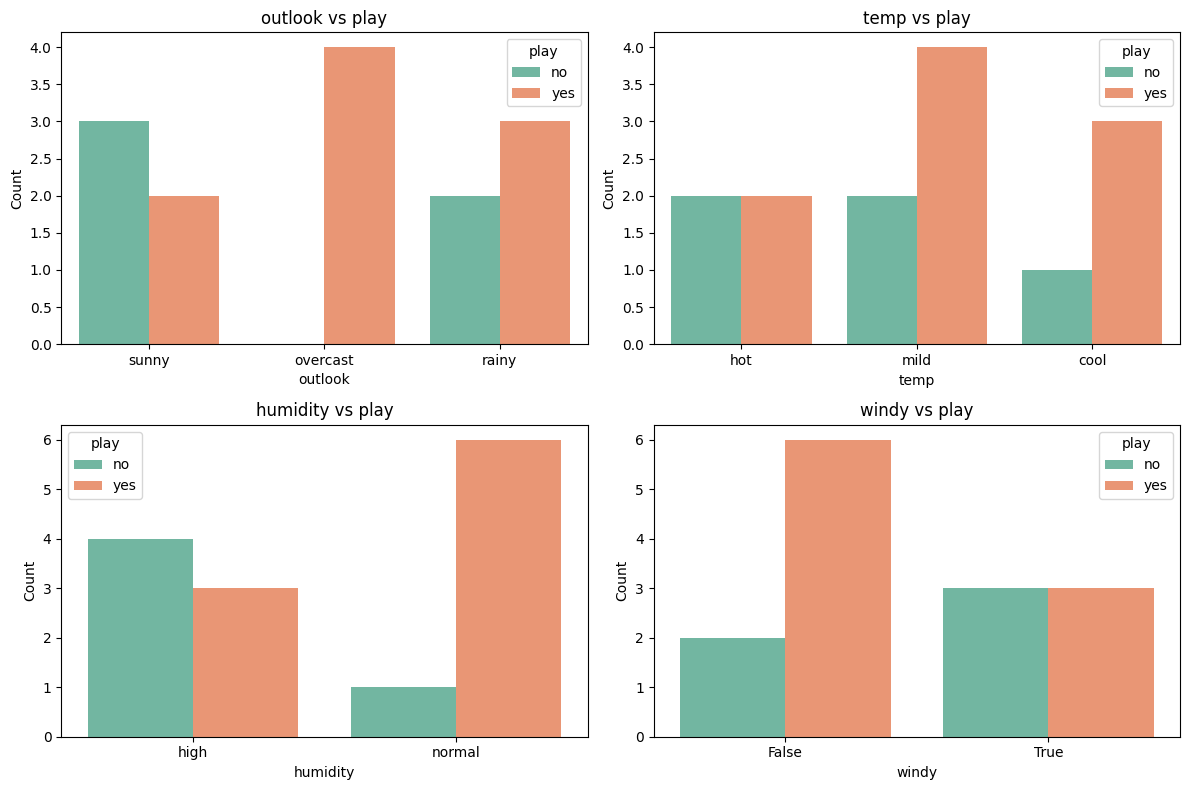

In [18]:
features = ["outlook", "temp", "humidity", "windy"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.flatten(), features):

    sns.countplot(
        data=df,
        x=feature,
        hue="play",
        palette="Set2",
        ax=ax
    )

    ax.set_title(f"{feature} vs play")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


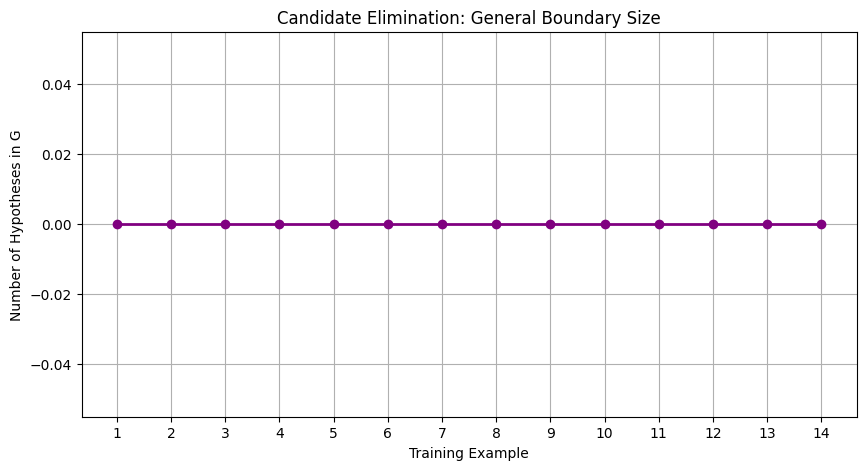

In [19]:
example_numbers = []
g_sizes = []

for step in history:

    example_numbers.append(
        step["example_number"]
    )

    g_sizes.append(
        len(step["G"])
    )

plt.figure(figsize=(10, 5))

plt.plot(
    example_numbers,
    g_sizes,
    marker="o",
    linewidth=2,
    color="purple"
)

plt.xlabel("Training Example")
plt.ylabel("Number of Hypotheses in G")

plt.title(
    "Candidate Elimination: "
    "General Boundary Size"
)

plt.xticks(example_numbers)

plt.grid(True)

plt.show()


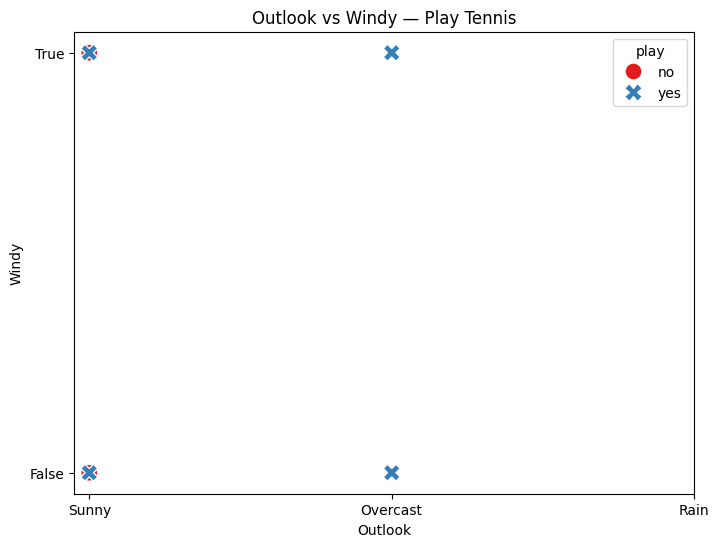

In [20]:
plot_df = df.copy()

outlook_map = {
    "sunny": 0,
    "overcast": 1,
    "rain": 2
}

wind_map = {
    "false": 0,
    "true": 1
}

plot_df["outlook_code"] = (
    plot_df["outlook"]
    .astype(str)
    .str.lower()
    .map(outlook_map)
)

plot_df["windy_code"] = (
    plot_df["windy"]
    .astype(str)
    .str.lower()
    .map(wind_map)
)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=plot_df,
    x="outlook_code",
    y="windy_code",
    hue="play",
    style="play",
    s=150,
    palette="Set1"
)

plt.xticks(
    [0, 1, 2],
    ["Sunny", "Overcast", "Rain"]
)

plt.yticks(
    [0, 1],
    ["False", "True"]
)

plt.xlabel("Outlook")
plt.ylabel("Windy")

plt.title("Outlook vs Windy — Play Tennis")

plt.show()
